### 환경설정
- chroma(벡터Db) : 로컬 인메모리 모드지원, 서버불필요
- Neo4j python driver : Neo4j 서버통신
- sentence-transformers : 텍스트 임베딩
- sckit-learn : PCA 데이터 분석

In [1]:
!pip install chromadb sentence-transformers neo4j matplotlib networkx scikit-learn -q

In [2]:
!pip install tf-keras

In [3]:
# 설치확인
import chromadb
import neo4j
import sentence_transformers
print(chromadb.__version__, neo4j.__version__, sentence_transformers.__version__)

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



1.5.9 6.2.0 5.5.1


### 벡터 DB
- 고차원 벡터(Embedding)를 저장, 유사도 검색을 수행하는데 특화
- RAG 핵심 인프라 : LLM의 외부 지식 검색에 필수적
- 메타데이터 필터링 : 벡터검색 + 조건 필터링 동시 지원

### 벡터 DB 종류
- Chroma : 경량 : 학습(프로토타입)
- Pinecone : 관리형, 고 가용성 : 대용량 프로젝트 
- Weaviate : 멀티모달         : 복합 검색
- Milvus : 분산처리 GPU       : 대용량 프로젝트
- FAISS : Meta 오픈소스, 초고속 : 연구용 (벤치마크)

In [4]:
import chromadb
client = chromadb.Client() # in-memory 방식  = 끄면 없어지고 유지하는 방식
# client = chromadb.PersistentClient(path='./outputs  ')
client.heartbeat() #

1779779816464006300

### collection 생성
- 벡터들의 논리적 그룹(RDBMS 테이블 개념)
- 거리함수 : cosine(기본)

In [5]:
collection = client.get_or_create_collection(
    name='korean_foods',          # 공백 → 언더스코어
    metadata={'hnsw:space': 'cosine'}  # 키 이름 공백 제거
)
print(f'컬렉션 이름 : {collection.name}')
print(f'현재 문서 수 : {collection.count()}')


컬렉션 이름 : korean_foods
현재 문서 수 : 0


In [6]:
documents = [
    "김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.",
    "불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.",
    "비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.",
    "된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.",
    "삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.",
    "떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.",
    "냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.",
    "잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.",
    "갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.",
    "순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.",
]

metadatas = [
    {"category": "찌개", "main_ingredient": "돼지고기", "spicy": True},
    {"category": "구이", "main_ingredient": "소고기", "spicy": False},
    {"category": "밥",  "main_ingredient": "채소",   "spicy": True},
    {"category": "찌개", "main_ingredient": "된장",   "spicy": False},
    {"category": "구이", "main_ingredient": "돼지고기", "spicy": False},
    {"category": "분식", "main_ingredient": "떡",     "spicy": True},
    {"category": "면",  "main_ingredient": "메밀",   "spicy": False},
    {"category": "볶음", "main_ingredient": "당면",   "spicy": False},
    {"category": "탕",  "main_ingredient": "소고기", "spicy": False},
    {"category": "찌개", "main_ingredient": "순두부", "spicy": True},
]

ids = [f'food_{i:03d}' for i in range(len(documents))]
print(f'ids : {ids}')

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f'{collection.count()}개 문서 추가 완료')
for doc_id, doc in zip(ids,documents):
    print(f' {doc_id} : {doc}')

ids : ['food_000', 'food_001', 'food_002', 'food_003', 'food_004', 'food_005', 'food_006', 'food_007', 'food_008', 'food_009']
10개 문서 추가 완료
 food_000 : 김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.
 food_001 : 불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.
 food_002 : 비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.
 food_003 : 된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.
 food_004 : 삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.
 food_005 : 떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.
 food_006 : 냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.
 food_007 : 잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.
 food_008 : 갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.
 food_009 : 순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.


### 유사도 검색

In [7]:
query  = '매운 국물 요리가 먹고 싶어요'
results = collection.query(
    query_texts=[query],
    n_results=5  # top_5
)
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    similarity = 1- dist # 코사인거리->유사도 변환
    print(doc,meta,dist)

떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다. {'main_ingredient': '떡', 'category': '분식', 'spicy': True} 0.15752524137496948
순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다. {'category': '찌개', 'main_ingredient': '순두부', 'spicy': True} 0.19012266397476196
김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다. {'category': '찌개', 'spicy': True, 'main_ingredient': '돼지고기'} 0.21276319026947021
냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다. {'main_ingredient': '메밀', 'spicy': False, 'category': '면'} 0.2229100465774536
잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다. {'spicy': False, 'category': '볶음', 'main_ingredient': '당면'} 0.25143176317214966


In [8]:
queries = [
    "고기를 구워서 먹는 음식",
    "시원한 여름 음식 추천해주세요",
    "명절에 먹는 전통 음식",
]

# 각 질문에 대해서 top-3 문장을 출력
for query in queries:
    results = collection.query(
        query_texts=[query],
        n_results=3  # top_5
    )
    print(f'\n질문 : {query}')
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')


질문 : 고기를 구워서 먹는 음식
유사도(0.7897407412528992) 문서:불고기는 간장 양념에 재운 ...,메타:{'main_ingredient': '소고기', 'category': '구이', 'spicy': False}
유사도(0.7736005783081055) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'main_ingredient': '떡', 'spicy': True}
유사도(0.7421424388885498) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'spicy': True, 'main_ingredient': '채소', 'category': '밥'}

질문 : 시원한 여름 음식 추천해주세요
유사도(0.7804622650146484) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'category': '밥', 'spicy': True, 'main_ingredient': '채소'}
유사도(0.7059831023216248) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'category': '면', 'spicy': False}
유사도(0.6690664887428284) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'spicy': True, 'main_ingredient': '돼지고기'}

질문 : 명절에 먹는 전통 음식
유사도(0.773314356803894) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'spicy': True, 'main_ingredient': '채소', 'category': '밥'}
유사도(0.7512445449829102) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'spicy': False, 'category': '면'}
유사도(0.7327145338058472) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'spicy'

### 메타데이터 필터링
- 기본 벡터유사도 검색 + 조건필터
- 문맥을 통해 유사한 문장을 찾으면서 특정조건을 만족하는 결과

In [9]:
# 매운음식만 검색 : 필터를 매운음식중에 국물요리 
results = collection.query(
        query_texts=["따뜻한 국물 요리"],
        n_results=3,  # top_5
        where={'spicy':True}  # 매운 음식만
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.7249371409416199) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}
유사도(0.6877250671386719) 문서:순두부찌개는 부드러운 순두부...,메타:{'category': '찌개', 'spicy': True, 'main_ingredient': '순두부'}
유사도(0.6661773324012756) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'main_ingredient': '떡', 'spicy': True, 'category': '분식'}


In [10]:
# 카테고리가 찌개인 음식
# 카테고리가 구이인 음식
# 소고기 또는 돼지고기를 사용하고 + 매운 음식이 아닌 것

In [11]:
results = collection.query(
        query_texts=["고기종류의 음식"],
        n_results=3,  # top_5
        where={
                "$and": [
                    { 'main_ingredient':{"$in":["소고기","돼지고기"]} },
                    { 'spicy':False }
                ]
            }
                
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.49335598945617676) 문서:불고기는 간장 양념에 재운 ...,메타:{'main_ingredient': '소고기', 'spicy': False, 'category': '구이'}
유사도(0.47859489917755127) 문서:갈비탕은 소갈비를 오랫동안 ...,메타:{'main_ingredient': '소고기', 'spicy': False, 'category': '탕'}
유사도(0.3948414921760559) 문서:삼겹살은 돼지 뱃살을 구워 ...,메타:{'main_ingredient': '돼지고기', 'category': '구이', 'spicy': False}


### 커스텀 임베딩 모델 사용
- Chroma 기본 임베딩 대신 Sentence-Transformer 다국어 모델을 사용해서 한국어 검색 성능을 향상

In [12]:
from chromadb.utils import embedding_functions
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='paraphrase-multilingual-MiniLM-L12-v2'
)

In [13]:
# 커스텀 임베딩 모델용 컬렉션 생성
collection_custom =  client.get_or_create_collection(
    name = 'korean_foods_custom',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_custom.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)
# 기본 vs 커스텀 임베딩
test_query = '뜨끈한 국물이 있는 겨울 음식'
r1 = collection.query(query_texts=[test_query],n_results=3)
r2 = collection_custom.query(query_texts=[test_query],n_results=3)

def showResult(results):
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
            similarity = 1- dist # 코사인거리->유사도 변환            
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
showResult(r1)
print('\n')
showResult(r2)

유사도(0.7687559127807617) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'spicy': True, 'main_ingredient': '떡'}
유사도(0.742857813835144) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}
유사도(0.6985085010528564) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'category': '면', 'spicy': False}


유사도(0.6097439527511597) 문서:잡채는 당면에 다양한 채소와...,메타:{'spicy': False, 'main_ingredient': '당면', 'category': '볶음'}
유사도(0.5943002700805664) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'spicy': False, 'category': '면'}
유사도(0.558979868888855) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'spicy': True, 'main_ingredient': '떡'}


### CRUD

In [14]:
# READ  ids로 조회
result = collection.get(ids = ["food_000","food_001"])
result

{'ids': ['food_000', 'food_001'],
 'embeddings': None,
 'documents': ['김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.',
  '불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True},
  {'category': '구이', 'main_ingredient': '소고기', 'spicy': False}]}

In [15]:
collection.update(
    ids = ["food_000"],
    documents=["김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다."],
    metadatas=[{'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}],    
)

In [16]:
print(collection.count())
collection.delete(ids = ['food_009'])
print(collection.count())

10
9


In [17]:
# 뉴스기사검색
# 카테고리분류 - NIP(자연어 모델로 자동 분류)
# documents + meta정보 생성
# VectorDB 구축(Chroma)
# mini RAG Retrieval : 검색 Augmentation: 증강 Generation: 생성

In [18]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import re
import sys
import json
import html
import urllib.request
from datetime import datetime
from dotenv import load_dotenv
load_dotenv(override=True)

def _format_date(pubdate):
    return datetime.strptime(pubdate, "%a, %d %b %Y %H:%M:%S %z").strftime("%Y-%m-%d")

def _format_str(text):
    return html.unescape(re.sub(r'<[^>]+>',"",text))

client_id = os.getenv('NAVER_CLIENT_ID')
client_secret = os.getenv('NAVER_CLIENT_SECETET')

items = []
def getNewsData(searchKeyword, category):
    encText = urllib.parse.quote(searchKeyword)
    url = "https://openapi.naver.com/v1/search/news?query=" + encText # JSON 결과
    # url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id",client_id)
    request.add_header("X-Naver-Client-Secret",client_secret)


    response = urllib.request.urlopen(request)
    rescode = response.getcode()
    if(rescode==200):
        response_body = response.read().decode('utf-8')
        result = json.loads(response_body)

        for row in result.get('items'):
            items.append({
                'title':_format_str(row.get('title')),
                'content':_format_str(row.get('description')),
                'category':category,
                'date':_format_date(row.get('pubDate')),
                'link':row.get('link')
            })         
getNewsData('인공지능','기술')
getNewsData('AI 반도체','기술')
getNewsData('전기차','자동차')
getNewsData('아파트','부동산')
getNewsData('취업','사회')

In [19]:
items

[{'title': '인천교통공사, 도시철도 역사·터널 미세먼지 개선사업 추진',
  'content': "공기질 통합 모니터링 시스템'을 한 단계 고도화하기로 했습니다. 또 11월까지 인공지능(AI) 기반 공기질 예측관리 시스템을 자체 개발해 기존 사후 대응 중심의 관리방식을 사전 예측 기반 대응체계로 전환할 계획입니다.",
  'category': '기술',
  'date': '2026-05-26',
  'link': 'http://news.lghellovision.net/news/articleView.html?idxno=543849'},
 {'title': 'GC녹십자, AI신기술·생산협력으로 사업경쟁력 강화… 증권가 "성장 본격...',
  'content': 'GC녹십자 본사 GC녹십자가 인공지능(AI) 기반 신기술 개발과 글로벌 기업과의 생산 협력을 잇따라 추진하며 사업 경쟁력 강화에 나섰다. 혈우병 치료의 디지털 전환과 핵심 바이오의약품의 안정적 생산 기반 확보를... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'http://www.biztribune.co.kr/news/articleView.html?idxno=354148'},
 {'title': "삼성E&A, 내달 2일 '테크포럼'…ADNOC·엑슨모빌 등 200개사 한자리에",
  'content': '△기존 화공 에너지원의 안정적 공급 지속 △수소·청정에너지·탄소포집(CCUS)·수처리 등 포트폴리오 다각화 △인공지능(AI)·디지털전환(DT)·로보틱스 기반 프로젝트 실행 가속화 등 세 축으로... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://www.webeconomy.co.kr/news/articleView.html?idxno=2181172'},
 {'title': '현대로템, 피지컬 AI 기반 무인로봇 국책개발 과제 2건 수주',
  'content': '현대로템

In [20]:
items[-5:]

[{'title': '대전 서구, 방위산업 시험인증 및 검·교정 전문 인력 양성 교육생 모집',
  'content': '청년들의 취업 경쟁력 강화를 위해 마련됐다. 교육은 6월 15일부터 8월 7일까지 주 4일(월~목) 과정으로 진행된다. 관련 분야의 이론과 실습 및 취업 연계가 합쳐진 현장 중심 과정으로 운영되며, 목원대학교 산학협력단이... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'http://www.gocj.net/news/articleView.html?idxno=148669'},
 {'title': '청주대, 지역 취업박람회 연계한 재학성 취업 기회 확대',
  'content': "청주대학교 대학일자리플러스센터는 지역 취업박람회와 연계한 재학생·졸업생 취업 지원에 나서고 있다고 밝혔습니다. 일자리플러스센터는 이달 초 열린 '2026 청주채용박람회'에 참여해 AI 기반 자기소개서 작성과... ",
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://news.bbsi.co.kr/news/articleView.html?idxno=4085662'},
 {'title': '[여의도1번지] 6·3 지방선거 D-8…스타벅스 논란 정치권 공방 격화',
  'content': '그런데, 김 후보가 대부업체에 "가족들 취업을 많이 시켜줬다"고 말한 녹취가 추가로 보도됐습니다. 유의동 후보와 조국 후보 측은 사퇴를 촉구했는데요. 김 후보의 대부업 의혹, 어떻게 보십니까? 평택을 판세에 영향을... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/422/0000868475?sid=100'},
 {'title': '당진여성새로일하기센터, 일자리 협력망 회의 개최',
  'content': '이번 회의는 사회복지실무자 양성과정에 

In [21]:
documents = []; metadatas = []
for row in items:
    documents.append(row.get('content')[:-3])
    metadatas.append(
    {
        'title':row.get('title'),
        'category':row.get('category'),
        'date':row.get('date'),
        'link':row.get('link')
    }
    )

### naver news 기반 검색 시스템 mini-RAG

In [22]:
# 크로마DB 객체 생성
# 뉴스컬렉션 생성  - 데이터베이스 테이블
# 기사 추가(컬렉션)
# 크로마DB가 제공하는 리트리버를 이용한 유사도기반의 문장 검색

news_client = chromadb.Client()  # in-memory
try:
    news_client.delete_collection('naver_news_api')
except Exception as e:
    print(e)


st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

collection_news =  news_client.get_or_create_collection(
    name = 'naver_news_api',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_news.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)

# 문서검색
query = '아파트'
query_filter = {'category': '부동산'}
results = collection_news.query(
    query_texts=[query],
    n_results=3,
    where=query_filter
)
showResult(results)

Collection [naver_news_api] does not exist
유사도(0.23508912324905396) 문서:한편, 공도스마트 IC 설치...,메타:{'title': "공도 스마트 IC 설치 두고 안성시장 후보들 '3인 3색' 답변", 'link': 'https://n.news.naver.com/mnews/article/666/0000108587?sid=100', 'date': '2026-05-26', 'category': '부동산'}
유사도(0.13905048370361328) 문서:이투데이=조유정 기자 | 2...,메타:{'category': '부동산', 'title': '국토부, 비아파트 공급 확대 드라이브…"현장 의견 지속 반영"[종합]', 'date': '2026-05-26', 'link': 'https://www.etoday.co.kr/news/view/2587830'}
유사도(0.13579297065734863) 문서:압구정3구역 재건축 정비사업...,메타:{'category': '부동산', 'date': '2026-05-26', 'title': '"이변은 없었다"…현대건설, \'압구정3구역\' 시공사로 선정', 'link': 'https://www.newspost.kr/news/articleView.html?idxno=223154'}


###  임베딩 시각화
- 문맥이 유사한 documents은 서로 가까이 배치(유사도가 높다)

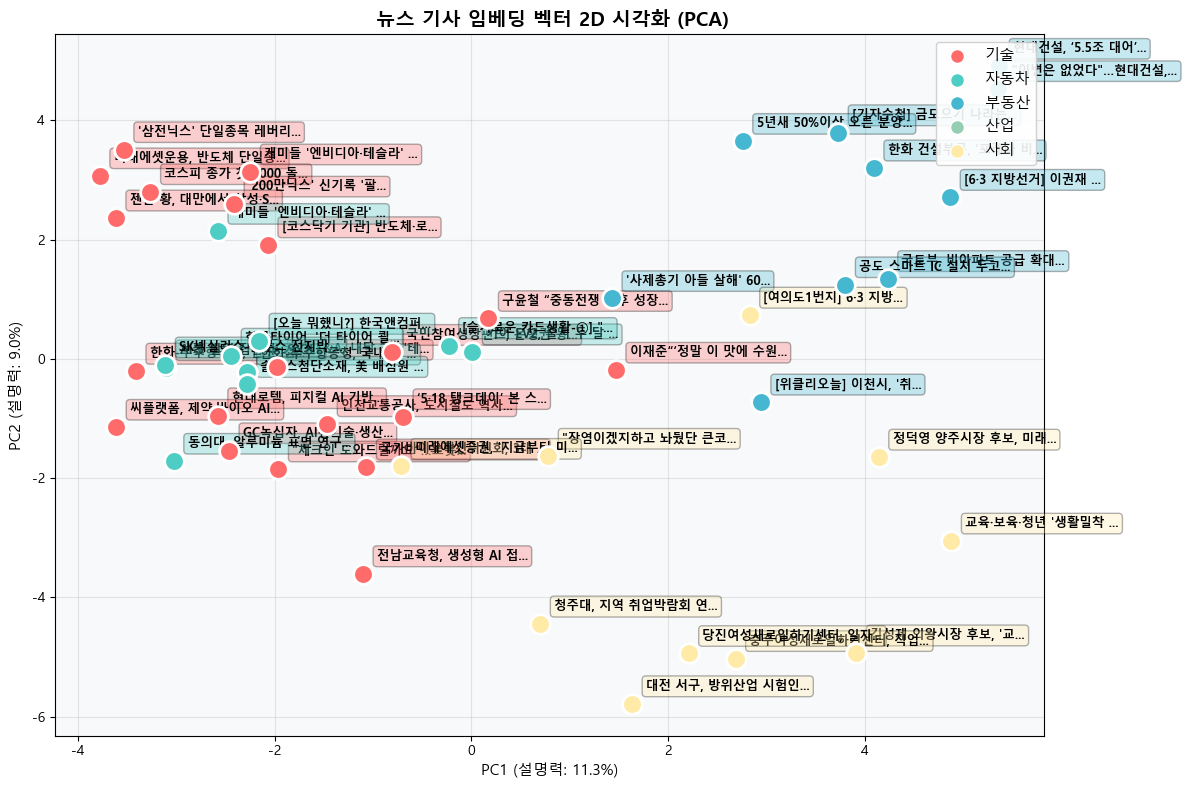


 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!


In [23]:
# ============================================================
# 임베딩 벡터 2D 시각화 (PCA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# matplotlib 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 뉴스 기사의 임베딩 벡터 가져오기
all_data = collection_news.get(
    include=["embeddings", "metadatas"]
)

embeddings = np.array(all_data['embeddings'])
categories = [m['category'] for m in all_data['metadatas']]
titles = [m['title'] for m in all_data['metadatas']]

# PCA로 2D 축소
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 카테고리별 색상
color_map = {
    "기술": "#FF6B6B",
    "자동차": "#4ECDC4",
    "부동산": "#45B7D1",
    "산업": "#96CEB4",
    "사회": "#FFEAA7",
}

for i, (x, y) in enumerate(coords):
    color = color_map.get(categories[i], "#999999")
    ax.scatter(x, y, c=color, s=200, edgecolors='white', linewidths=2, zorder=5)
    # 제목 줄이기
    short_title = titles[i][:15] + "..." if len(titles[i]) > 15 else titles[i]
    ax.annotate(short_title, (x, y), textcoords="offset points",
                xytext=(10, 10), fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

# 범례
for cat, color in color_map.items():
    ax.scatter([], [], c=color, s=100, label=cat, edgecolors='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax.set_title(' 뉴스 기사 임베딩 벡터 2D 시각화 (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 (설명력: {pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 (설명력: {pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print("\n 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!")

### 그래프 DB
- Node, RelationShip(관계), 탐색(Traversal) 통해서 복잡한 관계를 효율적으로 쿼리하는 데이터베이스
- Node : 엔티티(사람 장소 물건 등)를 나타내는 기본단위
- RelationShip : 노드간의 연결, 방향과 타입 보유
- Property(속서) : Node, Relation에 붙는 key-value데이터
- Label : 노드의 타입/카테고리
- RDBMS VS Graph DB
### 테이블(행,열) 노드 + 관계
- Join(외래키) 직접연결
- 다중 Join(느림) 그래프 탐색(빠름)
- 쿼리(SQL)언어 Neo4j
- 정형데이터, 집계 관계중심 데이터

In [27]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USER     = os.getenv('NEO4J_USERNAME')  
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE', 'neo4j')  # ← 추가 (기본값: 'neo4j')

from neo4j import GraphDatabase
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
neo4j_available = True

### Cypher 기본 문법
- 노드생성
    - CREATE(p:Person {name: 'kim', age: 28})
- 관계생성
    - MATCH(a:Person {name:'kim'}), (b:Person {name:'lee'})
    - CREATE (a) - [:FRIEND(Since:2020)] -> (b)
### 패턴 매칭
(a)-[:friend]->(b) a가 b의 친구

In [28]:
# 그래프 데이터 생성(Cypher 쿼리)

def run_cypher(query, parameters=None):
    """Neo4j에 Cypher 쿼리를 실행하고 결과를 반환합니다."""
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(query, parameters or {})
        return [record.data() for record in result]

if neo4j_available:
    # 기존 데이터 삭제
    run_cypher("MATCH (n) DETACH DELETE n")
    print("️ 기존 데이터 삭제 완료")
    
    # 노드 생성
    create_query = """
    CREATE (cs:Person {name: '김철수', age: 28, job: '개발자', city: '서울'})
    CREATE (yh:Person {name: '이영희', age: 32, job: '디자이너', city: '서울'})
    CREATE (ms:Person {name: '박민수', age: 25, job: '개발자', city: '부산'})
    CREATE (je:Person {name: '최지은', age: 30, job: 'PM', city: '서울'})
    CREATE (hj:Person {name: '정호진', age: 27, job: '데이터분석가', city: '대전'})
    CREATE (sj:Person {name: '한수진', age: 29, job: '개발자', city: '서울'})
    
    CREATE (cs)-[:FRIEND {since: 2020}]->(yh)
    CREATE (cs)-[:FRIEND {since: 2021}]->(ms)
    CREATE (yh)-[:COLLEAGUE {company: '테크Corp'}]->(je)
    CREATE (je)-[:MANAGES {since: 2022}]->(cs)
    CREATE (ms)-[:FRIEND {since: 2023}]->(hj)
    CREATE (hj)-[:COLLEAGUE {company: '데이터Lab'}]->(sj)
    CREATE (sj)-[:FRIEND {since: 2019}]->(cs)
    CREATE (yh)-[:FOLLOWS]->(hj)
    CREATE (je)-[:FOLLOWS]->(sj)
    
    RETURN count(*) as created
    """
    
    run_cypher(create_query)
    print(" Neo4j에 그래프 데이터 생성 완료!")
    
    # 확인
    result = run_cypher("MATCH (n:Person) RETURN n.name AS name, n.job AS job, n.city AS city")
    print(f"\n 생성된 노드:")
    for r in result:
        print(f"    {r['name']} — {r['job']}, {r['city']}")
else:
    print("️ Neo4j 서버에 연결되어 있지 않아 이 셀을 건너뜁니다.")
    print("   위의 Cypher 쿼리 코드를 읽으며 문법을 학습하세요.")

️ 기존 데이터 삭제 완료
 Neo4j에 그래프 데이터 생성 완료!

 생성된 노드:
    김철수 — 개발자, 서울
    이영희 — 디자이너, 서울
    박민수 — 개발자, 부산
    최지은 — PM, 서울
    정호진 — 데이터분석가, 대전
    한수진 — 개발자, 서울


In [29]:
if neo4j_available:
    print(" 1. 모든 FRIEND 관계 조회")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person)-[r:FRIEND]->(b:Person)
        RETURN a.name AS from_person, b.name AS to_person, r.since AS since
        ORDER BY r.since
    """)
    for r in results:
        print(f"  {r['from_person']} ──FRIEND──> {r['to_person']} (since {r['since']})")
    
    print(f"\n\n 2. 서울에 사는 개발자의 친구")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person {city: '서울', job: '개발자'})-[:FRIEND]->(b:Person)
        RETURN a.name AS person, b.name AS friend, b.city AS friend_city
    """)
    for r in results:
        print(f"  {r['person']}  {r['friend']} ({r['friend_city']})")
    
    print(f"\n\n 3. 2-hop 관계 탐색 (친구의 친구)")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person {name: '김철수'})-[:FRIEND]->()-[:FRIEND]->(fof:Person)
        WHERE fof.name <> '김철수'
        RETURN DISTINCT fof.name AS friend_of_friend, fof.job AS job
    """)
    for r in results:
        print(f"  김철수의 친구의 친구: {r['friend_of_friend']} ({r['job']})")
    
    print(f"\n\n 4. 최단 경로 탐색")
    print("="*50)
    results = run_cypher("""
        MATCH path = shortestPath(
            (a:Person {name: '김철수'})-[*]-(b:Person {name: '정호진'})
        )
        RETURN [node IN nodes(path) | node.name] AS path_nodes,
               length(path) AS hops
    """)
    for r in results:
        print(f"  경로: {'  '.join(r['path_nodes'])} ({r['hops']} hops)")

else:
    print("️ Neo4j 미연결 — Cypher 쿼리 코드를 읽으며 학습하세요.")
    print()
    print(" 위 코드에서 사용된 Cypher 패턴 정리:")
    print("   MATCH (a)-[r:TYPE]->(b)     : 패턴 매칭")
    print("   WHERE a.prop = 'value'       : 조건 필터링")
    print("   RETURN a.name, b.name        : 결과 반환")
    print("   (a)-[:FRIEND]->()-[:FRIEND]->(c) : 2-hop 탐색")
    print("   shortestPath((a)-[*]-(b))    : 최단 경로")

 1. 모든 FRIEND 관계 조회
  한수진 ──FRIEND──> 김철수 (since 2019)
  김철수 ──FRIEND──> 이영희 (since 2020)
  김철수 ──FRIEND──> 박민수 (since 2021)
  박민수 ──FRIEND──> 정호진 (since 2023)


 2. 서울에 사는 개발자의 친구
  김철수  이영희 (서울)
  김철수  박민수 (부산)
  한수진  김철수 (서울)


 3. 2-hop 관계 탐색 (친구의 친구)
  김철수의 친구의 친구: 정호진 (데이터분석가)


 4. 최단 경로 탐색
  경로: 김철수  박민수  정호진 (2 hops)
